# Comparação fuzzy no conjunto de teste

Este notebook resume os resultados salvos em `output/segmentation/runs/mid_res/fuzzy_comparison`.

O foco é comparar:

- detecção dos óstios;
- Dice score da segmentação arterial;
- impacto do fuzzy threshold, contextual fuzzy e fuzzy connectedness em relação ao baseline.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    from utils.project.notebook_env import configure_notebook_environment
    REPO_ROOT = configure_notebook_environment(chdir_to_src=False)
except Exception:
    current = Path.cwd().resolve()
    REPO_ROOT = next(
        path for path in [current, *current.parents]
        if (path / "src").exists() and (path / "output").exists()
    )

RESULT_ROOT = REPO_ROOT / "output/segmentation/runs/mid_res/fuzzy_comparison"
FIGURE_DIR = REPO_ROOT / "output/segmentation/analysis/fuzzy_comparison_eda/figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

RESULT_ROOT

def save_current_figure(name: str):
    path = FIGURE_DIR / name
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Figura salva em: {path.relative_to(REPO_ROOT)}")



## Carregamento dos resultados

A análise usa o `ostios_test_summary.csv` de cada variante como fonte principal, porque esse CSV registra por imagem o método de threshold, a aplicação contextual e o método arterial efetivamente usados.

In [2]:
SUCCESS_LABELS = {
    "both correct",
    "both tolerable",
    "both ostia correct",
    "both ostia tolerable",
}
CORRECT_LABELS = {"both correct", "both ostia correct"}
TOLERABLE_LABELS = {"both tolerable", "both ostia tolerable"}
WRONG_LABELS = {"found but incorrect", "found_but_wrong"}

PREFERRED_ORDER = [
    "normal_rg",
    "normal_contextual_rg",
    "th_fuzzy_rg",
    "th_fuzzy_contextual_rg",
    "normal_fc",
    "normal_contextual_fc",
    "th_fuzzy_fc",
    "th_fuzzy_contextual_fc",
]

PRETTY_NAMES = {
    "normal_rg": "Normal + RG",
    "normal_contextual_rg": "Normal + Contextual + RG",
    "th_fuzzy_rg": "Fuzzy threshold + RG",
    "th_fuzzy_contextual_rg": "Fuzzy threshold + Contextual + RG",
    "normal_fc": "Normal + FC",
    "normal_contextual_fc": "Normal + Contextual + FC",
    "th_fuzzy_fc": "Fuzzy threshold + FC",
    "th_fuzzy_contextual_fc": "Fuzzy threshold + Contextual + FC",
}


def yes_no_to_bool(series: pd.Series) -> pd.Series:
    return series.astype(str).str.lower().isin(["yes", "true", "1", "sim"])


def load_variant_run(summary_path: Path) -> tuple[pd.DataFrame, dict]:
    variant = summary_path.parents[2].name
    run_dir = summary_path.parents[1]
    df = pd.read_csv(summary_path)
    df["folder_variant"] = variant
    df["variant_label"] = PRETTY_NAMES.get(variant, variant)
    df["run_timestamp"] = run_dir.name
    df["run_dir"] = str(run_dir.relative_to(REPO_ROOT))
    df["artery_dice"] = pd.to_numeric(df["artery_dice"], errors="coerce")
    df["ostia_detected_bool"] = yes_no_to_bool(df["ostia_detected"])
    df["ostia_success"] = df["ostia_detection_status"].astype(str).isin(SUCCESS_LABELS)
    df["both_correct"] = df["ostia_detection_status"].astype(str).isin(CORRECT_LABELS)
    df["both_tolerable"] = df["ostia_detection_status"].astype(str).isin(TOLERABLE_LABELS)
    df["found_wrong"] = df["ostia_detection_status"].astype(str).isin(WRONG_LABELS)

    summary = {
        "folder_variant": variant,
        "variant_label": PRETTY_NAMES.get(variant, variant),
        "run_timestamp": run_dir.name,
        "run_dir": str(run_dir.relative_to(REPO_ROOT)),
        "n_images": len(df),
        "threshold_mode": df["threshold_mode"].iloc[0],
        "contextual_apply_to": df["contextual_apply_to"].iloc[0],
        "artery_method": df["configured_artery_segmentation_method"].iloc[0],
        "ostia_detected_rate": df["ostia_detected_bool"].mean(),
        "ostia_success_rate": df["ostia_success"].mean(),
        "both_correct_n": int(df["both_correct"].sum()),
        "both_tolerable_n": int(df["both_tolerable"].sum()),
        "found_wrong_n": int(df["found_wrong"].sum()),
        "not_found_or_error_n": int((~(df["ostia_success"] | df["found_wrong"])).sum()),
        "mean_dice": df["artery_dice"].mean(),
        "median_dice": df["artery_dice"].median(),
        "std_dice": df["artery_dice"].std(),
        "mean_dice_success_ostia": df.loc[df["ostia_success"], "artery_dice"].mean(),
        }
    return df, summary

all_frames = []
summary_rows = []
for summary_path in sorted(RESULT_ROOT.glob("*/*/numeric/ostios_test_summary.csv")):
    df_variant, summary = load_variant_run(summary_path)
    all_frames.append(df_variant)
    summary_rows.append(summary)

results_df = pd.concat(all_frames, ignore_index=True)
summary_df = pd.DataFrame(summary_rows)
summary_df["order"] = summary_df["folder_variant"].map({name: idx for idx, name in enumerate(PREFERRED_ORDER)})
summary_df = summary_df.sort_values(["order", "folder_variant"]).drop(columns="order")

print(f"Runs carregados: {summary_df.shape[0]}")
print(f"Linhas por imagem: {results_df.shape[0]}")
display(summary_df)

Runs carregados: 8
Linhas por imagem: 5600


,folder_variant,variant_label,run_timestamp,run_dir,n_images,threshold_mode,contextual_apply_to,artery_method,ostia_detected_rate,ostia_success_rate,both_correct_n,both_tolerable_n,found_wrong_n,not_found_or_error_n,mean_dice,median_dice,std_dice,mean_dice_success_ostia
3,normal_rg,Normal + RG,2026-06-22_10-18-31,output/segmentation/runs/mid_res/fuzzy_compari...,700,normal,none,rg,0.994286,0.808571,60,506,130,4,0.578427,0.652087,0.196185,0.649271
1,normal_contextual_rg,Normal + Contextual + RG,2026-06-20_23-21-01,output/segmentation/runs/mid_res/fuzzy_compari...,700,normal,artery,rg,0.994286,0.812857,61,508,127,4,0.578133,0.650889,0.194917,0.646771
7,th_fuzzy_rg,Fuzzy threshold + RG,2026-06-20_08-33-25,output/segmentation/runs/mid_res/fuzzy_compari...,700,fuzzy,none,rg,0.990000,0.808571,51,515,127,7,0.580936,0.653493,0.195601,0.651245
5,th_fuzzy_contextual_rg,Fuzzy threshold + Contextual + RG,2026-06-19_09-14-58,output/segmentation/runs/mid_res/fuzzy_compari...,700,fuzzy,artery,rg,0.990000,0.808571,51,515,127,7,0.581141,0.651509,0.194396,0.651081
2,normal_fc,Normal + FC,2026-06-19_09-20-42,output/segmentation/runs/mid_res/fuzzy_compari...,700,normal,none,fc,0.994286,0.808571,60,506,130,4,0.564721,0.636069,0.193130,0.631494
0,normal_contextual_fc,Normal + Contextual + FC,2026-06-21_12-41-04,output/segmentation/runs/mid_res/fuzzy_compari...,700,normal,artery,fc,0.994286,0.808571,60,506,130,4,0.565458,0.635903,0.193319,0.632727
6,th_fuzzy_fc,Fuzzy threshold + FC,2026-06-20_23-26-14,output/segmentation/runs/mid_res/fuzzy_compari...,700,fuzzy,none,fc,0.990000,0.808571,51,515,127,7,0.562797,0.637484,0.193844,0.627929
4,th_fuzzy_contextual_fc,Fuzzy threshold + Contextual + FC,2026-06-19_23-26-51,output/segmentation/runs/mid_res/fuzzy_compari...,700,fuzzy,artery,fc,0.990000,0.808571,51,515,127,7,0.563442,0.637900,0.195416,0.629617


## Resumo geral

A tabela abaixo ordena as variantes por sucesso dos óstios e Dice médio. O sucesso dos óstios considera `both correct` ou `both tolerable` como sucesso.

In [3]:
ranking_df = summary_df.sort_values(
    ["ostia_success_rate", "mean_dice", "mean_dice_success_ostia"],
    ascending=False,
).copy()

ranking_display = ranking_df[[
    "variant_label",
    "threshold_mode",
    "contextual_apply_to",
    "artery_method",
    "n_images",
    "ostia_detected_rate",
    "ostia_success_rate",
    "both_correct_n",
    "both_tolerable_n",
    "found_wrong_n",
    "not_found_or_error_n",
    "mean_dice",
    "median_dice",
    "mean_dice_success_ostia",
]].copy()

for col in ["ostia_detected_rate", "ostia_success_rate"]:
    ranking_display[col] = 100 * ranking_display[col]

display(ranking_display.round({
    "ostia_detected_rate": 1,
    "ostia_success_rate": 1,
    "mean_dice": 4,
    "median_dice": 4,
    "mean_dice_success_ostia": 4,
}))

,variant_label,threshold_mode,contextual_apply_to,artery_method,n_images,ostia_detected_rate,ostia_success_rate,both_correct_n,both_tolerable_n,found_wrong_n,not_found_or_error_n,mean_dice,median_dice,mean_dice_success_ostia
1,Normal + Contextual + RG,normal,artery,rg,700,99.4,81.3,61,508,127,4,0.5781,0.6509,0.6468
5,Fuzzy threshold + Contextual + RG,fuzzy,artery,rg,700,99.0,80.9,51,515,127,7,0.5811,0.6515,0.6511
7,Fuzzy threshold + RG,fuzzy,none,rg,700,99.0,80.9,51,515,127,7,0.5809,0.6535,0.6512
3,Normal + RG,normal,none,rg,700,99.4,80.9,60,506,130,4,0.5784,0.6521,0.6493
0,Normal + Contextual + FC,normal,artery,fc,700,99.4,80.9,60,506,130,4,0.5655,0.6359,0.6327
2,Normal + FC,normal,none,fc,700,99.4,80.9,60,506,130,4,0.5647,0.6361,0.6315
4,Fuzzy threshold + Contextual + FC,fuzzy,artery,fc,700,99.0,80.9,51,515,127,7,0.5634,0.6379,0.6296
6,Fuzzy threshold + FC,fuzzy,none,fc,700,99.0,80.9,51,515,127,7,0.5628,0.6375,0.6279


## Detecção dos óstios

Aqui o status é separado em: ambos corretos, ambos toleráveis, encontrados porém incorretos e não encontrado/erro.

Figura salva em: output/segmentation/analysis/fuzzy_comparison_eda/figures/ostia_status_by_variant.png


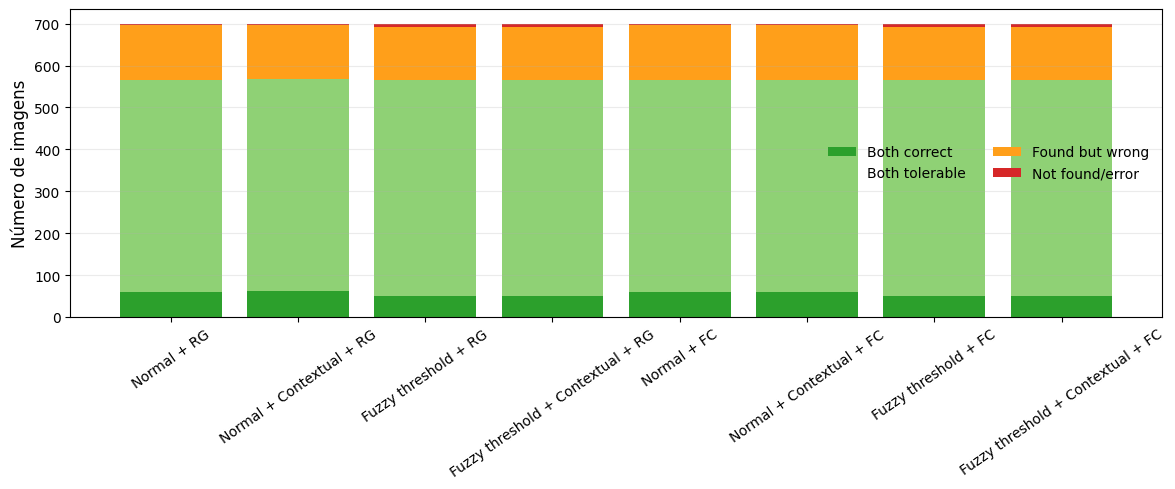

In [4]:
ostia_plot = summary_df.copy()
ostia_plot["variant_label"] = pd.Categorical(
    ostia_plot["variant_label"],
    [PRETTY_NAMES.get(name, name) for name in PREFERRED_ORDER],
    ordered=True,
)
ostia_plot = ostia_plot.sort_values("variant_label")

status_cols = ["both_correct_n", "both_tolerable_n", "found_wrong_n", "not_found_or_error_n"]
status_labels = ["Both correct", "Both tolerable", "Found but wrong", "Not found/error"]
colors = ["#2ca02c", "#8fd175", "#ff9f1a", "#d62728"]

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(ostia_plot))
for col, label, color in zip(status_cols, status_labels, colors):
    values = ostia_plot[col].to_numpy()
    ax.bar(ostia_plot["variant_label"].astype(str), values, bottom=bottom, label=label, color=color)
    bottom += values
ax.set_ylabel("Número de imagens", fontsize=12)
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=35, labelsize=10)
ax.legend(ncol=2, frameon=False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
save_current_figure("ostia_status_by_variant.png")
plt.show()

## Dice score por variante

Os gráficos abaixo mostram a média/mediana e a distribuição do Dice arterial por variante.

Figura salva em: output/segmentation/analysis/fuzzy_comparison_eda/figures/dice_mean_median_by_variant.png


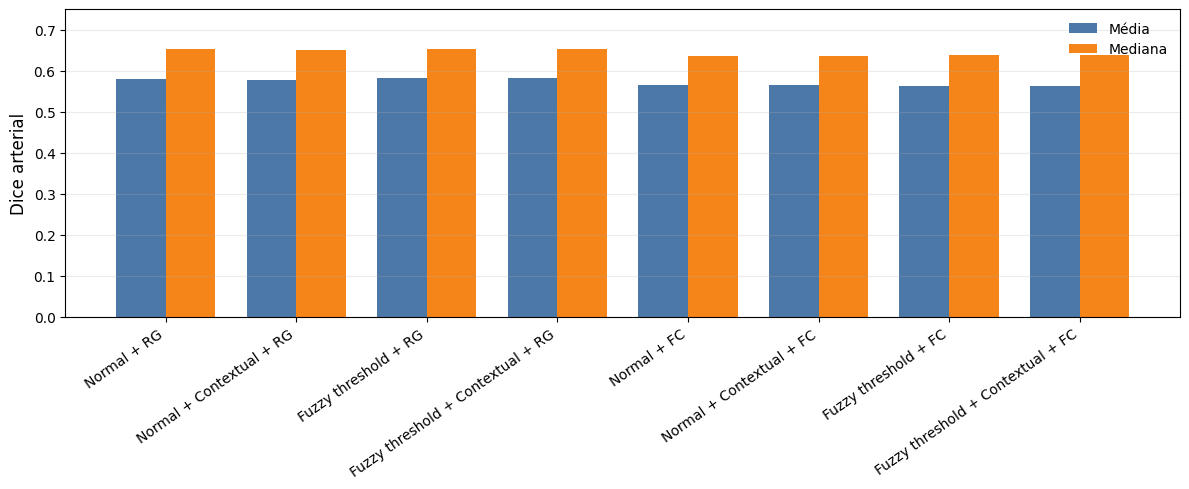

In [5]:
dice_plot = summary_df.copy()
dice_plot["variant_label"] = pd.Categorical(
    dice_plot["variant_label"],
    [PRETTY_NAMES.get(name, name) for name in PREFERRED_ORDER],
    ordered=True,
)
dice_plot = dice_plot.sort_values("variant_label")

x = np.arange(len(dice_plot))
width = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, dice_plot["mean_dice"], width, label="Média", color="#4c78a8")
ax.bar(x + width/2, dice_plot["median_dice"], width, label="Mediana", color="#f58518")
ax.set_xticks(x)
ax.set_xticklabels(dice_plot["variant_label"].astype(str), rotation=35, ha="right")
ax.set_ylabel("Dice arterial", fontsize=12)
ax.set_ylim(0, max(0.75, float(dice_plot[["mean_dice", "median_dice"]].max().max()) + 0.05))
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
save_current_figure("dice_mean_median_by_variant.png")
plt.show()

/tmp/ipykernel_19616/768478355.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=ordered_labels, showfliers=False)


Figura salva em: output/segmentation/analysis/fuzzy_comparison_eda/figures/dice_distribution_by_variant.png


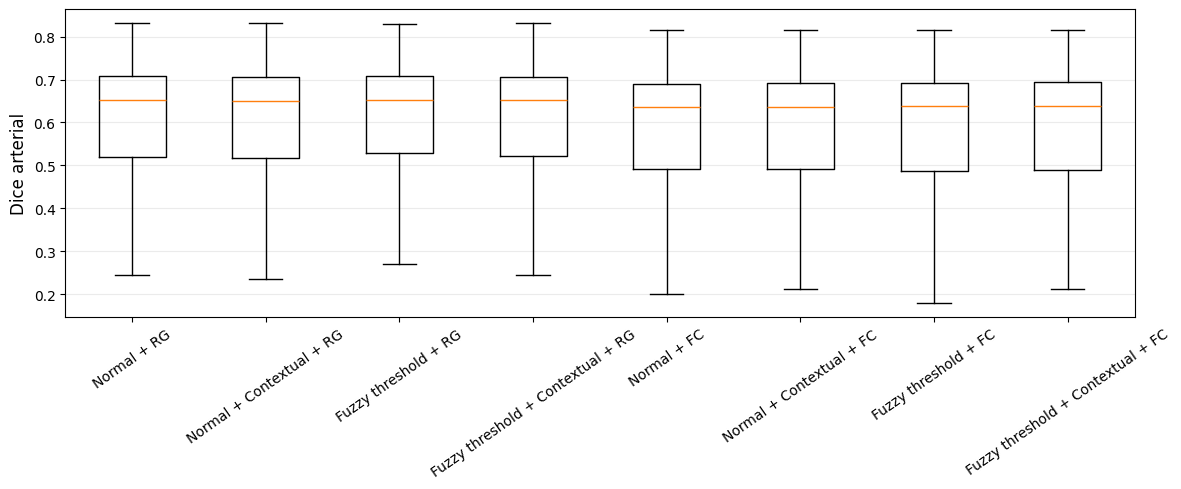

In [6]:
ordered_labels = [PRETTY_NAMES.get(name, name) for name in PREFERRED_ORDER if name in set(results_df["folder_variant"])]
box_data = [
    results_df.loc[results_df["variant_label"] == label, "artery_dice"].dropna().to_numpy()
    for label in ordered_labels
]

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(box_data, labels=ordered_labels, showfliers=False)
ax.set_ylabel("Dice arterial", fontsize=12)
ax.tick_params(axis="x", rotation=35, labelsize=10)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
save_current_figure("dice_distribution_by_variant.png")
plt.show()

## Comparação com baseline

A célula abaixo usa `Normal + RG` como baseline e calcula o ganho/perda de Dice por imagem.

In [7]:
baseline_variant = "normal_rg"
baseline = results_df.loc[
    results_df["folder_variant"] == baseline_variant,
    ["IMG_ID", "artery_dice", "ostia_detection_status"],
].rename(columns={"artery_dice": "baseline_dice", "ostia_detection_status": "baseline_ostia_status"})

delta_rows = []
for variant in PREFERRED_ORDER:
    if variant == baseline_variant or variant not in set(results_df["folder_variant"]):
        continue
    current = results_df.loc[
        results_df["folder_variant"] == variant,
        ["IMG_ID", "artery_dice", "ostia_detection_status"],
    ].rename(columns={"artery_dice": "variant_dice", "ostia_detection_status": "variant_ostia_status"})
    merged = baseline.merge(current, on="IMG_ID", how="inner")
    merged["dice_delta"] = merged["variant_dice"] - merged["baseline_dice"]
    delta_rows.append({
        "folder_variant": variant,
        "variant_label": PRETTY_NAMES.get(variant, variant),
        "mean_delta": merged["dice_delta"].mean(),
        "median_delta": merged["dice_delta"].median(),
        "improved_ge_0_02": int((merged["dice_delta"] >= 0.02).sum()),
        "worse_le_minus_0_02": int((merged["dice_delta"] <= -0.02).sum()),
        "max_gain": merged["dice_delta"].max(),
        "max_loss": merged["dice_delta"].min(),
    })

delta_summary_df = pd.DataFrame(delta_rows).sort_values("mean_delta", ascending=False)
display(delta_summary_df.round({
    "mean_delta": 4,
    "median_delta": 4,
    "max_gain": 4,
    "max_loss": 4,
}))

,folder_variant,variant_label,mean_delta,median_delta,improved_ge_0_02,worse_le_minus_0_02,max_gain,max_loss
2,th_fuzzy_contextual_rg,Fuzzy threshold + Contextual + RG,0.0027,0.0005,82,61,0.7957,-0.7349
1,th_fuzzy_rg,Fuzzy threshold + RG,0.0025,0.0001,78,62,0.7976,-0.7349
0,normal_contextual_rg,Normal + Contextual + RG,-0.0003,0.0002,26,22,0.3689,-0.4119
4,normal_contextual_fc,Normal + Contextual + FC,-0.0130,-0.0076,84,213,0.3286,-0.3567
3,normal_fc,Normal + FC,-0.0137,-0.0077,89,212,0.3198,-0.3780
6,th_fuzzy_contextual_fc,Fuzzy threshold + Contextual + FC,-0.0150,-0.0087,115,243,0.7920,-0.7349
5,th_fuzzy_fc,Fuzzy threshold + FC,-0.0156,-0.0094,123,256,0.7917,-0.7349


Figura salva em: output/segmentation/analysis/fuzzy_comparison_eda/figures/dice_delta_vs_normal_rg.png


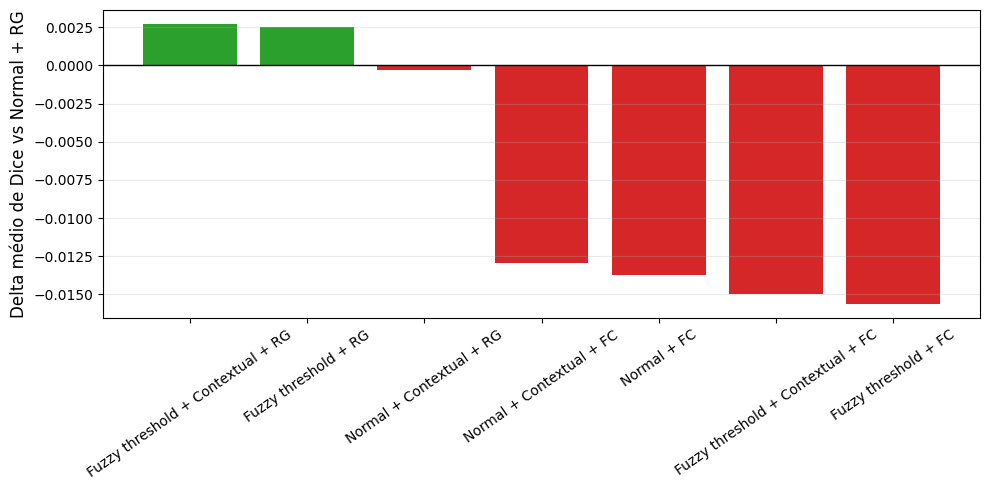

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_delta = delta_summary_df.copy()
colors = ["#2ca02c" if value >= 0 else "#d62728" for value in plot_delta["mean_delta"]]
ax.bar(plot_delta["variant_label"], plot_delta["mean_delta"], color=colors)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Delta médio de Dice vs Normal + RG", fontsize=12)
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=35, labelsize=10)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
save_current_figure("dice_delta_vs_normal_rg.png")
plt.show()

## Casos de maior ganho e maior perda

Esta seção ajuda a escolher imagens para inspeção visual posterior.

In [9]:
def variant_delta_cases(variant: str, top_n: int = 10) -> tuple[pd.DataFrame, pd.DataFrame]:
    current = results_df.loc[
        results_df["folder_variant"] == variant,
        ["IMG_ID", "artery_dice", "ostia_detection_status", "artery_voxel_count"],
    ].rename(columns={
        "artery_dice": "variant_dice",
        "ostia_detection_status": "variant_ostia_status",
        "artery_voxel_count": "variant_artery_voxels",
    })
    merged = baseline.merge(current, on="IMG_ID", how="inner")
    merged["dice_delta"] = merged["variant_dice"] - merged["baseline_dice"]
    return (
        merged.sort_values("dice_delta", ascending=False).head(top_n),
        merged.sort_values("dice_delta", ascending=True).head(top_n),
    )

best_variant = ranking_df.iloc[0]["folder_variant"]
print(f"Melhor variante no ranking: {PRETTY_NAMES.get(best_variant, best_variant)}")
gains, losses = variant_delta_cases(best_variant, top_n=10)

print("Maiores ganhos vs Normal + RG")
display(gains)
print("Maiores perdas vs Normal + RG")
display(losses)

Melhor variante no ranking: Normal + Contextual + RG
Maiores ganhos vs Normal + RG


,IMG_ID,baseline_dice,baseline_ostia_status,variant_dice,variant_ostia_status,variant_artery_voxels,dice_delta
535,49,0.341571,found but incorrect,0.710466,both tolerable,33955.0,0.368895
601,212,0.000000,found but incorrect,0.357785,found but incorrect,19314.0,0.357785
278,171,0.133817,both tolerable,0.393096,both tolerable,10035.0,0.259280
452,452,0.393191,found but incorrect,0.635133,both tolerable,25751.0,0.241942
231,994,0.447372,both tolerable,0.574988,both tolerable,43901.0,0.127616
244,374,0.472900,found but incorrect,0.597650,both tolerable,23801.0,0.124750
133,995,0.212443,found but incorrect,0.332464,found but incorrect,6252.0,0.120021
113,833,0.639457,both tolerable,0.757220,both tolerable,39672.0,0.117763
87,741,0.440356,both tolerable,0.547854,both tolerable,8790.0,0.107498
419,500,0.031534,found but incorrect,0.106046,both tolerable,5873.0,0.074512


Maiores perdas vs Normal + RG


,IMG_ID,baseline_dice,baseline_ostia_status,variant_dice,variant_ostia_status,variant_artery_voxels,dice_delta
63,287,0.718831,both tolerable,0.306926,found but incorrect,20729.0,-0.411904
584,826,0.402047,found but incorrect,0.000000,found but incorrect,482.0,-0.402047
647,864,0.746830,both tolerable,0.431989,both correct,16778.0,-0.314841
626,141,0.703841,both tolerable,0.457966,found but incorrect,12556.0,-0.245875
215,397,0.648569,both tolerable,0.434210,both tolerable,13333.0,-0.214358
61,147,0.722115,both tolerable,0.515055,found but incorrect,15109.0,-0.207059
412,801,0.584059,both tolerable,0.395507,both tolerable,54431.0,-0.188553
288,302,0.541037,both tolerable,0.359829,both tolerable,11089.0,-0.181208
509,775,0.438520,both tolerable,0.267280,both tolerable,5111.0,-0.171240
627,973,0.772309,both tolerable,0.619702,found but incorrect,18578.0,-0.152607


## Leitura inicial dos resultados atuais

Com os resultados atualmente salvos em `fuzzy_comparison`, a tendência principal é:

- as variantes com `RG` ficam acima das variantes com `FC` em Dice médio;
- o fuzzy threshold melhora levemente o Dice médio quando combinado com `RG`, mas perde um pouco na taxa de óstios bem-sucedidos;
- o contextual fuzzy aplicado ao vesselness arterial muda pouco no agregado;
- `FC` ajuda alguns casos individuais, mas no conjunto completo fica abaixo do `RG`.

Use as tabelas de delta para selecionar casos específicos de inspeção visual.